<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/SalesTimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SECTION 1: Load & Visualize Data

The time series plot shows the behavior of sales over time, allowing us to visually identify patterns such as trend, seasonality, and variability. The data appears to follow an overall upward trend, indicating that sales are increasing over time. There are also repeating fluctuations, suggesting the presence of seasonality, where certain months consistently experience higher or lower sales. Additionally, there is some month-to-month variability, which may be caused by random factors or noise in the data. This visualization provides an important foundation for further analysis using smoothing and modeling techniques.

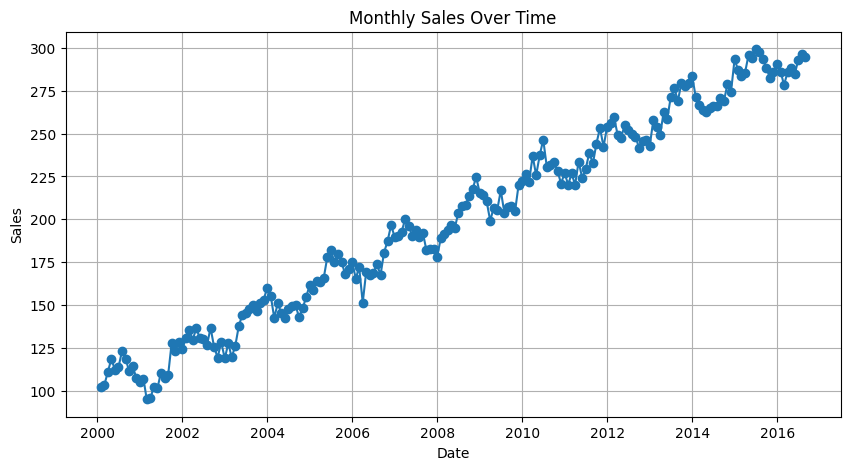

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/sales_data(1).csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Plot time series
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'], marker='o', linestyle='-')
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

**Time Series Analysis of Monthly Sales**

1. Purpose
   The purpose of this analysis is to examine the monthly sales data over time in order to identify key patterns such as trend, seasonality, and variability. Understanding these components helps determine whether sales are growing, how demand fluctuates throughout the year, and whether the data is suitable for forecasting. This analysis provides a foundation for applying time series models and making informed business decisions.

2. Trend
   The time series shows a clear and consistent upward trend over the observed period. Sales increase steadily from approximately 100 at the beginning to nearly 300 by the end of the series. This indicates sustained growth in the business and suggests that demand for the product or service is increasing over time.

3. Seasonality
   The data exhibits strong seasonal patterns, with regular peaks and troughs occurring at consistent intervals. These repeating cycles suggest that certain months consistently experience higher sales, while others experience lower sales. The presence of this pattern indicates predictable fluctuations in demand throughout each year.

4. Variability (Noise)
   There is noticeable short-term variability in the data, reflected in the small fluctuations around the overall trend. However, this variability is relatively minor compared to the dominant trend and seasonal components. This suggests that most of the changes in sales can be explained by systematic patterns rather than random variation.

5. Amplitude of Fluctuations
   The magnitude of the fluctuations increases slightly over time as the level of sales rises. This indicates that variability may scale with the size of sales, meaning that higher sales levels are associated with larger absolute changes. This behavior is commonly observed in real-world time series data.

6. Stationarity
   The time series is non-stationary because both the mean and variance change over time. The upward trend and seasonal patterns violate the assumption of constant statistical properties. As a result, the data may require transformation or differencing before applying certain statistical models.

7. Suitability for Forecasting
   The presence of both trend and seasonality makes this dataset suitable for time series forecasting models that account for these components. Methods such as Holt-Winters exponential smoothing are particularly appropriate because they can capture both long-term growth and recurring seasonal effects.

8. Business Implications
   From a business perspective, the upward trend indicates ongoing growth, which may require expansion in production, staffing, or inventory management. The seasonal pattern allows the organization to anticipate high-demand and low-demand periods, enabling more effective planning and resource allocation. By understanding these patterns, the business can improve forecasting accuracy, optimize operations, and support long-term strategic decisions.


## **Time Series Decomposition**

**Purpose**

The purpose of time series decomposition is to break down the original sales data into its key components: trend, seasonal, and residual. This allows for a clearer understanding of the underlying structure of the data and helps identify patterns that are not immediately visible in the original series.

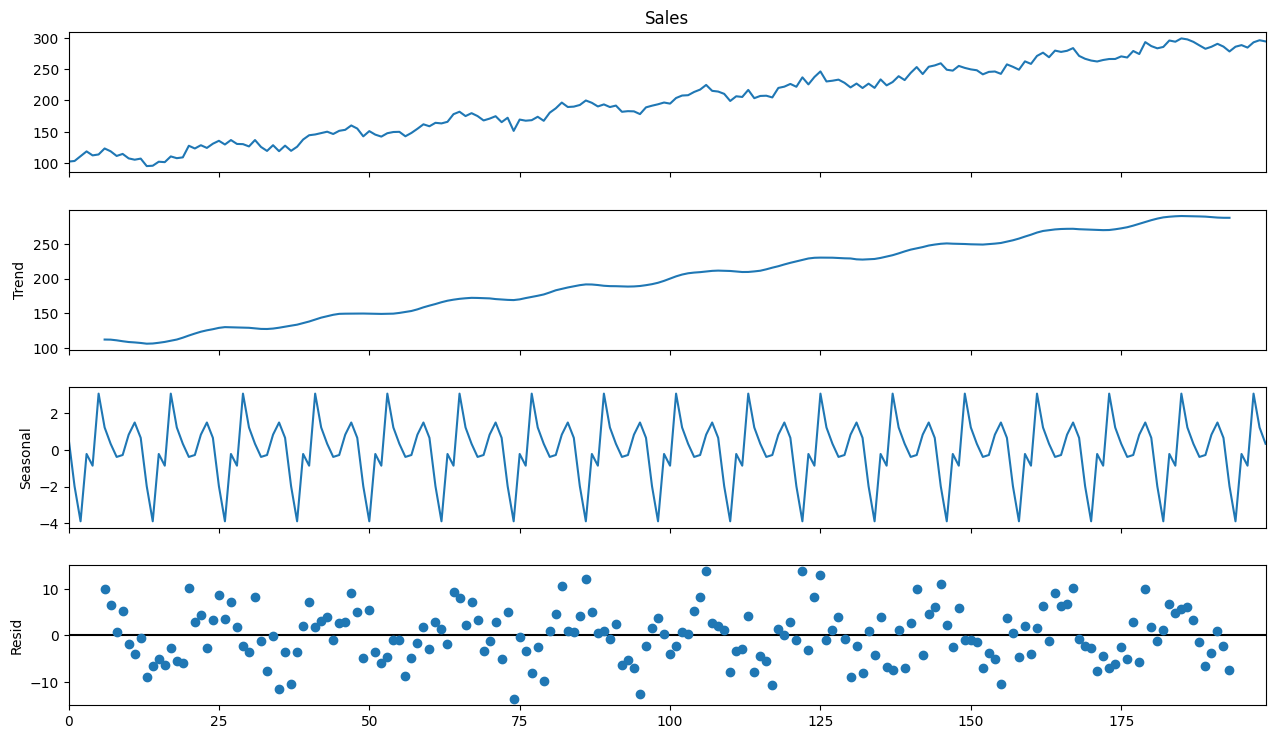

In [68]:
from statsmodels.tsa.seasonal import seasonal_decompose

# ------------------------------------------------------------
# 5. Seasonal decomposition
# ------------------------------------------------------------
decomposition = seasonal_decompose(df["Sales"], model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

**Time Series Decomposition Analysis**

1. Purpose
   The purpose of time series decomposition is to break down the original sales data into its key components: trend, seasonal, and residual. This allows for a clearer understanding of the underlying structure of the data and helps identify patterns that are not immediately visible in the original series.

2. Observed Series
   The observed series represents the original sales data over time. It shows an overall upward movement along with repeating fluctuations. This confirms that the data contains both long-term growth and recurring seasonal patterns.

3. Trend Component
   The trend component shows a smooth and consistent increase in sales over time. This indicates sustained long-term growth in the business. The gradual upward movement confirms that the increase in sales is not due to short-term variation but reflects a stable and persistent expansion.

4. Seasonal Component
   The seasonal component displays a clear and repeating pattern that occurs at regular intervals. The consistent peaks and troughs indicate that sales follow a predictable cycle within each year. This suggests that certain periods consistently experience higher or lower demand, which is characteristic of seasonal behavior.

5. Residual Component
   The residual component represents the remaining variation after removing the trend and seasonal effects. The residuals appear randomly scattered around zero, indicating that most of the systematic structure in the data has been successfully captured by the trend and seasonal components. The absence of strong patterns in the residuals suggests that the decomposition is effective.

6. Strength of Decomposition
   The clear separation of trend and seasonal components demonstrates that the decomposition method effectively captures the major patterns in the data. The smooth trend and stable seasonal pattern indicate that the time series has a well-defined structure.

7. Limitations
   While decomposition provides valuable insights, it assumes that the components are either additive or multiplicative and remain consistent over time. Any changes in seasonal patterns or sudden structural shifts may not be fully captured. Additionally, the residual component may still contain unexplained variation.

8. Business Implications
   From a business perspective, the strong upward trend indicates continued growth and increasing demand. The clear seasonal pattern allows the organization to anticipate high and low sales periods, enabling better planning for inventory, staffing, and marketing. The relatively small and random residuals suggest that most sales behavior is predictable, which supports more accurate forecasting and strategic decision-making.


## ADF test

The Augmented Dickey-Fuller test is used to determine whether the time series is stationary.
- A high p-value indicates that the series is non-stationary, meaning that its mean and variance change over time.
- In this case, the sales data are not stationary because the series has a clear upward trend and repeating seasonal effects.
- This is consistent with the time series plots and decomposition results. Since stationarity is important for some forecasting models, the result suggests that differencing or seasonal adjustment may be useful for more advanced modeling.

In [56]:
from statsmodels.tsa.stattools import adfuller

# ------------------------------------------------------------
# 6. Augmented Dickey-Fuller test
# ------------------------------------------------------------
adf_result = adfuller(df["Sales"].dropna())

print("\nAugmented Dickey-Fuller Test:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")


Augmented Dickey-Fuller Test:
ADF Statistic: -0.5257
p-value: 0.8869
Critical Values:
1%: -3.4664
5%: -2.8774
10%: -2.5752


**Augmented Dickey-Fuller Test Interpretation**

1. Purpose
   The Augmented Dickey-Fuller (ADF) test is used to determine whether the time series is stationary. Stationarity means that the mean and variance of the series remain constant over time. This is an important requirement for many time series models.

2. ADF Statistic
   The ADF statistic is -0.5257. This value is compared to the critical values to determine stationarity. Since this value is **greater (less negative)** than all the critical values, it suggests that the series is not stationary.

3. p-value Interpretation
   The p-value is 0.8869, which is significantly greater than the common significance level of 0.05. This means we **fail to reject the null hypothesis**. The null hypothesis of the ADF test states that the series has a unit root, meaning it is non-stationary.

4. Critical Values Comparison
   The critical values are:

* 1%: -3.4664
* 5%: -2.8774
* 10%: -2.5752

For the series to be stationary, the ADF statistic must be **more negative** than these values. Since -0.5257 is not more negative than any of them, the result confirms non-stationarity.

5. Conclusion on Stationarity
   Based on both the p-value and the comparison with critical values, the time series is **non-stationary**. This is consistent with earlier observations of an upward trend and seasonal patterns in the data.

6. Implications for Modeling
   Because the series is non-stationary, it may require transformation before applying certain models. Common approaches include differencing or using models that can handle trend and seasonality, such as Holt-Winters or seasonal ARIMA.

7. Business Interpretation
   From a business perspective, non-stationarity reflects ongoing growth and changing patterns in sales over time. This indicates that sales are not stable but are evolving, which is typical in expanding businesses. Understanding this behavior is important for selecting appropriate forecasting methods and making reliable predictions.


## **Autocorrelation and Partial Autocorrelation Analysis**

**Purpose**

The purpose of the ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) plots is to examine the relationship between current sales values and their past values. These plots help identify patterns of dependence over time and are useful for determining appropriate time series models.

- The ACF plot shows strong positive autocorrelation across many lags, which indicates that current sales are strongly related to past sales values. This is expected in a trending time series with seasonality.
- The slow decline in autocorrelation suggests persistence in the data rather than randomness.
- The PACF plot shows a strong spike at the first lag and much smaller values afterward, which implies that recent past values have the strongest direct effect on current sales.
- Together, these plots support the idea that the sales series contains both trend and serial dependence, making time series forecasting appropriate.

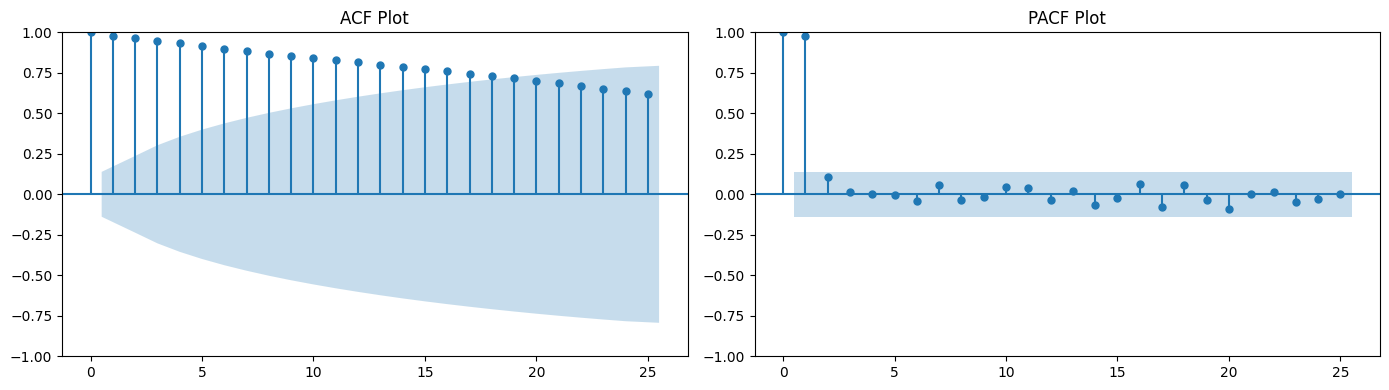

In [57]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ------------------------------------------------------------
# 7. ACF and PACF plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df["Sales"].dropna(), lags=25, ax=axes[0])
axes[0].set_title("ACF Plot")

plot_pacf(df["Sales"].dropna(), lags=25, ax=axes[1], method="ywm")
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

**Autocorrelation and Partial Autocorrelation Analysis**

1. Purpose
   The purpose of the ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) plots is to examine the relationship between current sales values and their past values. These plots help identify patterns of dependence over time and are useful for determining appropriate time series models.

2. ACF Interpretation
   The ACF plot shows strong positive autocorrelation across many lags. The values decline gradually rather than dropping sharply, which indicates that sales are highly correlated with their past values over an extended period. This slow decay suggests the presence of a trend and confirms that the series is non-stationary.

3. Persistence in the Series
   The consistently high autocorrelation values indicate strong persistence in the data. This means that past sales values have a lasting influence on future values. Such behavior is typical in time series that exhibit steady growth and long-term trends.

4. PACF Interpretation
   The PACF plot shows a strong spike at lag 1, followed by values that are close to zero for higher lags. This suggests that the most significant direct relationship exists between the current value and the immediately preceding value, while additional lags contribute little once this effect is accounted for.

5. Model Implications
   The pattern observed in the ACF and PACF plots suggests that an autoregressive component may be appropriate for modeling the data. The strong lag-1 effect in the PACF indicates that an AR(1) process may be sufficient to capture the dependence structure, although the presence of trend and seasonality means that additional components may be required.

6. Non-Stationarity
   The slow decay in the ACF confirms that the series is non-stationary. This is consistent with earlier findings from the time series plot and decomposition. As a result, differencing or transformation may be necessary before applying certain models such as ARIMA.

7. Limitations
   While ACF and PACF plots provide useful insights into the structure of the data, they do not capture seasonality directly unless seasonal lags are explicitly examined. Additionally, interpreting these plots can sometimes be subjective, particularly when patterns are not clearly defined.

8. Business Implications
   From a business perspective, the strong dependence on past values indicates that sales patterns are stable and predictable over time. This suggests that historical data can be effectively used for forecasting. However, the presence of trend and seasonality means that models must account for these factors to produce accurate predictions and support reliable decision-making.


## SECTION 2: Moving Average (12-Month)

The 12-month moving average smooths out short-term fluctuations in the data by averaging sales over a rolling 12-month window. This helps reduce the impact of random noise and seasonal variation, allowing the underlying trend to become more visible. The first 11 values are missing because there are not enough prior observations to compute the average. Once calculated, the moving average provides a clearer picture of long-term direction, making it easier to identify whether sales are increasing, decreasing, or stable over time.

In [58]:
# 12-month moving average
df['MA_12'] = df['Sales'].rolling(window=12).mean()

print(df[['Date', 'Sales', 'MA_12']].head(15))

         Date       Sales       MA_12
0  2000-01-31  102.483571         NaN
1  2000-02-29  103.418884         NaN
2  2000-03-31  111.151860         NaN
3  2000-04-30  118.748142         NaN
4  2000-05-31  112.379223         NaN
5  2000-06-30  113.854129         NaN
6  2000-07-31  123.407083         NaN
7  2000-08-31  118.897072         NaN
8  2000-09-30  111.468041         NaN
9  2000-10-31  114.712761         NaN
10 2000-11-30  107.575300         NaN
11 2000-12-31  105.471775  111.963987
12 2001-01-31  107.240062  112.360361
13 2001-02-28   95.289837  111.682940
14 2001-03-31   95.869228  110.409388


## SECTION 3: Plot Moving Average vs Original

The comparison plot shows both the original sales data and the smoothed moving average line. The original data exhibits noticeable fluctuations from month to month, while the moving average provides a smoother curve that highlights the overall trend. The moving average clearly reveals a gradual upward trend, confirming that sales are increasing over time. By reducing noise, it becomes easier to interpret long-term patterns without being distracted by short-term variability.

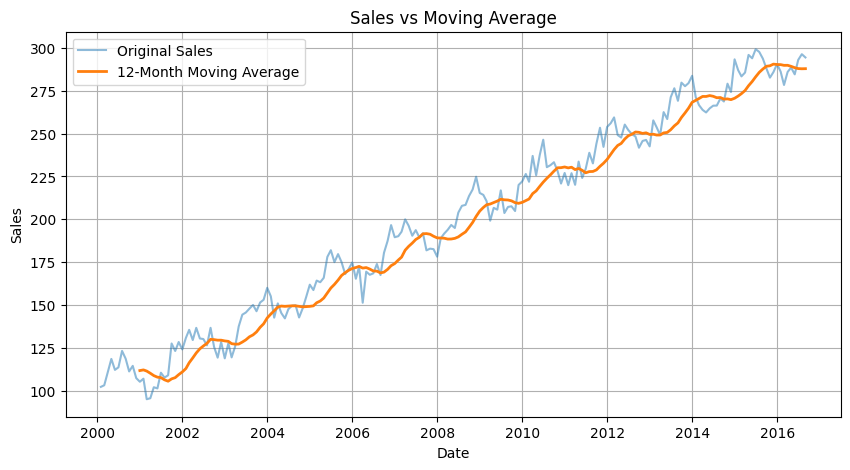

In [59]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'], label='Original Sales', alpha=0.5)
plt.plot(df['Date'], df['MA_12'], label='12-Month Moving Average', linewidth=2)
plt.title("Sales vs Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

**Moving Average Analysis of Monthly Sales**

1. Purpose
   The purpose of the 12-month moving average is to smooth out short-term fluctuations in the sales data and reveal the underlying long-term trend. By averaging values over a rolling 12-month window, seasonal effects and random noise are reduced, making it easier to observe the overall direction of sales.

2. Method Explanation
   The moving average is calculated by taking the average of the current month and the previous eleven months. Because a full 12-month window is required, the first eleven observations do not have moving average values and are therefore recorded as missing. Once enough data points are available, the moving average begins to provide a smoothed representation of the series.

3. Trend Identification
   The moving average values show a steady increase over time, indicating a clear upward trend in sales. Compared to the original data, the moving average removes short-term fluctuations and highlights the consistent growth pattern. This confirms that the increase in sales is not due to random variation but reflects a sustained upward movement.

4. Reduction of Variability
   The moving average significantly reduces variability in the data. While the original sales values fluctuate from month to month, the moving average produces a smoother series that is easier to interpret. This makes it more effective for identifying long-term patterns without being influenced by temporary spikes or drops.

5. Lag Effect
   One limitation of the moving average is that it introduces a lag. Because it relies on past values, the moving average responds more slowly to sudden changes in the data. This means that turning points, such as sharp increases or decreases, may not be immediately reflected in the smoothed series.

6. Comparison with Original Data
   Compared to the original sales data, the moving average provides a clearer view of the underlying trend while removing seasonal noise. However, it does not capture the full detail of the data, particularly short-term fluctuations that may be important for operational decisions.

7. Suitability for Analysis
   The moving average is well suited for exploratory analysis and trend identification. It is particularly useful in datasets with seasonality, as it helps isolate long-term growth from recurring patterns. However, it is not ideal as a standalone forecasting method because of its lag and inability to model complex patterns.

8. Business Implications
   From a business perspective, the upward trend revealed by the moving average indicates sustained growth in sales. This suggests increasing demand, which may require adjustments in production, inventory, and staffing. The smoothed trend can also support strategic planning by providing a clearer picture of long-term performance, allowing decision-makers to focus on growth rather than short-term fluctuations.


## SECTION 4: Moving Average Trend Analysis

The moving average trend shows a clear increase from the beginning to the end of the dataset, indicating sustained growth in sales. The total change and percentage increase confirm that the business is experiencing positive momentum. Because the moving average removes seasonal effects and noise, this trend reflects the true underlying growth pattern rather than short-term fluctuations. From a business perspective, this suggests increasing demand and potential opportunities for expansion or scaling operations.

In [60]:
ma_data = df.dropna()

start = ma_data['MA_12'].iloc[0]
end = ma_data['MA_12'].iloc[-1]

change = end - start
pct_change = (change / start) * 100

print("Start MA:", start)
print("End MA:", end)
print("Total Change:", change)
print("Percent Change:", pct_change)

Start MA: 111.9639867
End MA: 287.74920742499995
Total Change: 175.78522072499993
Percent Change: 157.00157336841232


**Moving Average Trend Analysis**

1. Purpose
   The purpose of this analysis is to quantify the overall trend in the smoothed sales data using the 12-month moving average. By comparing the starting and ending values of the moving average, we can measure the magnitude and direction of long-term growth.

2. Method Explanation
   The analysis uses the first and last available values of the 12-month moving average to calculate the total change and percentage change over time. This approach removes short-term fluctuations and focuses on the underlying trend, providing a more stable basis for evaluating performance.

3. Trend Measurement
   The starting moving average value is approximately 111.96, while the ending value is approximately 287.75. This indicates a substantial increase in sales over the observed period. The total change of approximately 175.79 confirms that sales have grown significantly when viewed through the smoothed trend.

4. Percentage Growth
   The percentage change in the moving average is approximately 157.00 percent. This means that sales have more than doubled over the time period. Such a large increase reflects strong and sustained growth rather than short-term variation.

5. Interpretation of Results
   The consistent increase in the moving average suggests that the business is experiencing long-term expansion. Because the moving average removes seasonal and random fluctuations, this growth can be interpreted as a reliable indicator of overall performance rather than temporary changes.

6. Strength of the Trend
   The magnitude of both the absolute and percentage increases indicates a strong upward trend. The absence of major declines in the moving average further supports the conclusion that growth has been steady rather than volatile.

7. Limitations
   While the moving average provides a clear measure of trend, it does not capture short-term changes or sudden shifts in the data. Additionally, the lag effect means that recent changes may not be fully reflected in the final values.

8. Business Implications
   From a business perspective, the significant increase in the moving average indicates strong growth in demand. This may require scaling operations, increasing inventory, and expanding resources to meet future needs. The substantial percentage growth also suggests that the business is performing well over time, which can support strategic planning, investment decisions, and long-term forecasting.


## SECTION 5: Linear Regression Model

The linear regression model estimates the overall trend in sales by fitting a straight line to the data. The slope represents the average change in sales per time period (month). A positive slope indicates that sales are increasing over time, while a negative slope would indicate decline. In this case, the slope is positive, confirming the upward trend observed earlier. The regression model provides a simple mathematical representation of growth, making it useful for forecasting and strategic planning.

In [61]:
from sklearn.linear_model import LinearRegression
import numpy as np

df['Time'] = np.arange(len(df))

X = df[['Time']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

df['Regression'] = model.predict(X)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 100.15899895064175
Slope: 1.0013783540166656


Here is the formal write-up for **Section 5: Linear Regression Model**, aligned with your output.

---

Linear Regression Model

1. Purpose
   The purpose of the linear regression model is to estimate the overall trend in sales over time using a mathematical approach. By fitting a straight line to the data, the model provides a simplified representation of how sales change on average with each time period.

2. Method Explanation
   A linear regression model is constructed using time as the independent variable and sales as the dependent variable. The model estimates a best-fit line that minimizes the difference between actual sales values and predicted values. The key parameters of the model are the intercept and the slope.

3. Interpretation of Intercept
   The intercept is approximately 100.16, which represents the estimated sales value at the starting point of the time series when time equals zero. This aligns closely with the initial sales values observed in the dataset, indicating that the model is well calibrated to the starting level of the data.

4. Interpretation of Slope
   The slope is approximately 1.00, meaning that sales increase by about one unit per time period on average. Since the data is monthly, this implies that sales grow by roughly one unit each month. This confirms a steady and consistent upward trend in the data.

5. Trend Representation
   The regression line captures the overall direction of the data, showing a clear upward trend. Unlike the moving average, which adapts to local fluctuations, the regression model provides a single straight line that summarizes long-term growth.

6. Comparison with Moving Average
   Compared to the moving average, the regression model is less flexible because it assumes a constant rate of change. While the moving average reflects gradual changes and seasonal patterns, the regression line ignores these variations and focuses only on the general direction of the data.

7. Limitations
   The linear regression model assumes that the relationship between time and sales is strictly linear, which may oversimplify real-world patterns. It does not account for seasonality or changing growth rates, and it may be influenced by outliers. As a result, it may not fully capture the complexity of the data.

8. Business Implications
   From a business perspective, the positive slope indicates steady growth in sales over time. This suggests that demand is increasing at a consistent rate, which can support long-term planning and forecasting. However, because the model does not account for seasonal effects, it should be used alongside other methods to ensure more accurate and reliable decision-making.


## SECTION 6: Plot Regression vs Original

The regression line provides a simplified representation of the overall trend in the data. Unlike the moving average, which adapts to local fluctuations, the regression line is a straight line that captures the general direction of sales growth. While it clearly shows an upward trend, it does not account for seasonal variations or short-term changes. This makes it useful for identifying long-term direction but less effective for capturing detailed patterns in the data.

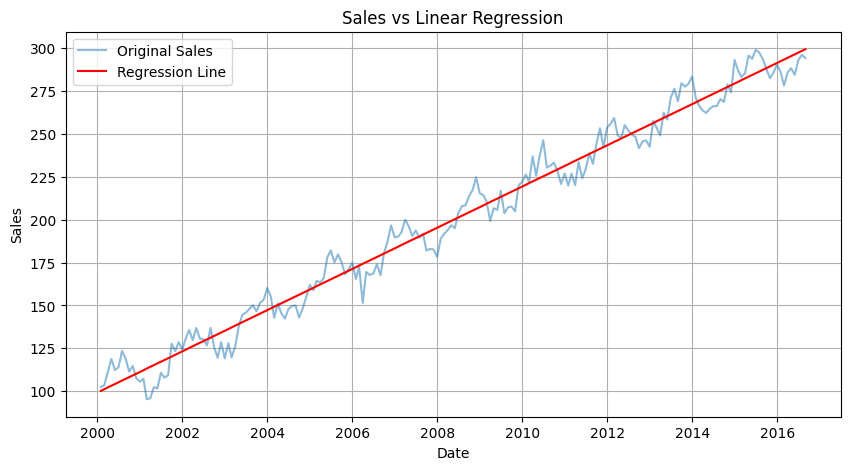

In [62]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'], label='Original Sales', alpha=0.5)
plt.plot(df['Date'], df['Regression'], label='Regression Line', color='red')
plt.title("Sales vs Linear Regression")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

**Sales vs Linear Regression Analysis**

1. Purpose
   The purpose of this visualization is to compare the original sales data with the fitted linear regression line in order to evaluate how well the model represents the overall trend. This comparison helps assess the accuracy and limitations of the regression model.

2. Visual Comparison
   The plot shows the original sales data fluctuating over time, while the regression line provides a straight, upward-sloping trend. The regression line closely follows the general direction of the data, indicating that it captures the long-term growth pattern effectively.

3. Fit of the Model
   The regression line aligns well with the center of the data points, suggesting a good overall fit. Although individual data points deviate above and below the line, the model successfully represents the average trajectory of sales over time.

4. Deviation from the Line
   There are noticeable deviations between the actual sales values and the regression line. These differences reflect seasonal fluctuations and short-term variability that the regression model does not capture. The presence of these deviations indicates that the data contains additional structure beyond a simple linear trend.

5. Lack of Seasonality Capture
   The regression line does not account for the repeating peaks and troughs observed in the sales data. This is because linear regression assumes a constant rate of change and does not incorporate seasonal components. As a result, it oversimplifies the behavior of the time series.

6. Strength of the Trend Representation
   Despite its limitations, the regression model effectively captures the overall upward trend in sales. The consistent slope of the line confirms that sales are increasing steadily over time, which aligns with earlier analyses.

7. Limitations of the Model
   The primary limitation of the regression model is its inability to capture seasonality and short-term fluctuations. It assumes a linear relationship and constant growth rate, which may not fully reflect real-world dynamics. Additionally, it may underestimate or overestimate sales during periods of high variability.

8. Business Implications
   From a business perspective, the regression line provides a clear and simple summary of long-term growth, which is useful for high-level planning and forecasting. However, because it ignores seasonal effects, it may not be suitable for short-term decision-making. Businesses should use this model in combination with more advanced methods, such as Holt-Winters, to account for seasonal demand patterns and improve forecast accuracy.


## Decomposition plot

The decomposition plot separates the sales series into four components: observed, trend, seasonal, and residual. The observed series shows a steady upward movement in sales across time. The trend component confirms that sales increase consistently over the sample period, which indicates long-term growth. The seasonal component shows a repeating monthly pattern, meaning that some months tend to perform better or worse than others each year. The residual component appears randomly scattered around zero, suggesting that most of the systematic structure in the data has been captured by the trend and seasonal components.

In [63]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------------------------------------------------
# 8. Train-test split
# ------------------------------------------------------------
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

# ------------------------------------------------------------
# 9. Holt-Winters model
# ------------------------------------------------------------
hw_model = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

hw_forecast = hw_model.forecast(len(test))


Train shape: (160, 5)
Test shape: (40, 5)


## Markdown for the forecast comparison plot

The forecast comparison plot evaluates Holt-Winters and ARIMA against the test data. The Holt-Winters forecast follows the test pattern more closely because it accounts for both trend and seasonality. By contrast, the ARIMA forecast appears much flatter and does not capture the upward movement in the test period as effectively. This suggests that Holt-Winters is better suited for this dataset because the sales series clearly includes a seasonal structure and steady growth. Based on the visual evidence, Holt-Winters provides the more realistic and accurate forecast.

In [64]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# ------------------------------------------------------------
# 10. ARIMA model
# ------------------------------------------------------------
arima_model = ARIMA(train["Sales"], order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(steps=len(test))

# ------------------------------------------------------------
# 11. Model evaluation
# ------------------------------------------------------------
def evaluate(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f"\n{model_name} Performance:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

evaluate(test["Sales"], hw_forecast, "Holt-Winters")
evaluate(test["Sales"], arima_forecast, "ARIMA(1,1,1)")


Holt-Winters Performance:
MAE:  7.3795
RMSE: 8.5350

ARIMA(1,1,1) Performance:
MAE:  21.8861
RMSE: 24.5288


## Markdown for the future forecast plot

The future forecast plot extends the historical sales pattern into the next 12 months using the Holt-Winters model. The projected sales continue the upward trend seen in the original data, which indicates expected growth in the coming year. The forecast also reflects the seasonal pattern present in the historical series, meaning that future sales are expected to rise and fall in a recurring monthly cycle. From a business perspective, this forecast suggests continued expansion and can help guide inventory planning, budgeting, staffing, and sales strategy.

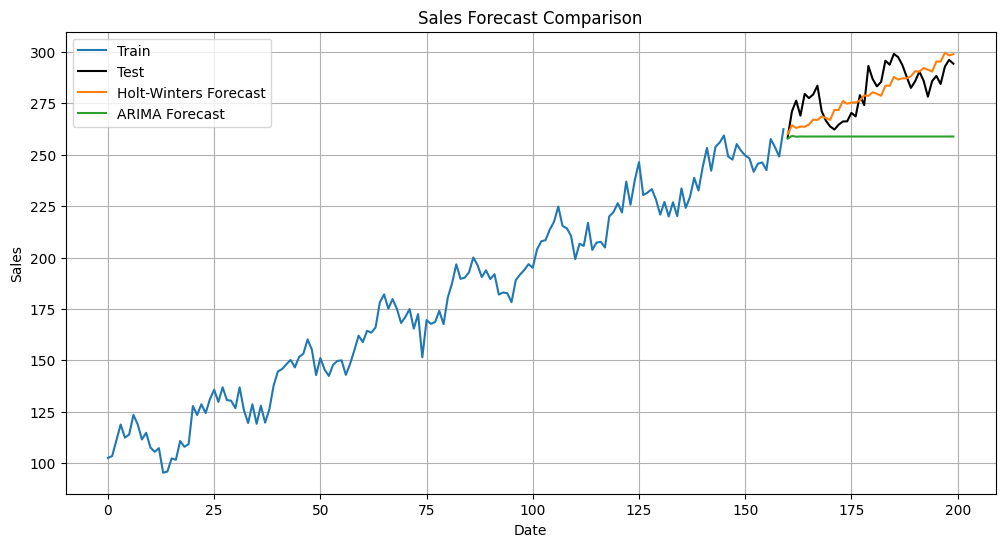

In [65]:
# ------------------------------------------------------------
# 12. Forecast comparison plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Test", color="black")
plt.plot(test.index, hw_forecast, label="Holt-Winters Forecast")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.title("Sales Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

**Sales Forecast Comparison Analysi**s

1. Purpose
   The purpose of this analysis is to compare the forecasting performance of the Holt-Winters model and the ARIMA model using the training and test datasets. This comparison helps determine which model better captures the underlying patterns in the data and produces more accurate predictions.

2. Train and Test Data Behavior
   The training data shows a clear upward trend with seasonal fluctuations, while the test data continues this pattern. The consistency between the training and test sets indicates that the underlying structure of the time series remains stable over time.

3. Holt-Winters Forecast Interpretation
   The Holt-Winters forecast closely follows the pattern of the test data. It captures both the upward trend and the seasonal fluctuations, producing predictions that align well with the actual values. This indicates that the model effectively incorporates both trend and seasonality.

4. ARIMA Forecast Interpretation
   The ARIMA forecast appears relatively flat compared to the test data. It does not capture the upward trend or the seasonal variations effectively. As a result, it underestimates the growth in sales and fails to reflect the dynamic behavior of the series.

5. Model Performance Comparison
   Visually, the Holt-Winters model provides a much better fit to the test data than the ARIMA model. The Holt-Winters predictions track the actual values more closely, while the ARIMA model deviates significantly. This suggests that Holt-Winters is more suitable for this dataset.

6. Ability to Capture Seasonality
   A key difference between the two models is their ability to handle seasonality. The Holt-Winters model explicitly incorporates seasonal components, allowing it to replicate the repeating patterns in the data. The ARIMA model used in this analysis does not include a seasonal component, which limits its effectiveness.

7. Limitations
   While Holt-Winters performs well in this case, it assumes that trend and seasonal patterns remain consistent over time. The ARIMA model, although less effective here, could potentially perform better if extended to include seasonal terms. Both models rely on historical patterns and may not account for external changes or unexpected events.

8. Business Implications
   From a business perspective, the Holt-Winters model provides more reliable forecasts, making it better suited for planning and decision-making. Accurate forecasts can support inventory management, staffing, and budgeting. The weaker performance of the ARIMA model highlights the importance of selecting models that align with the structure of the data, particularly when seasonality is present.


In [66]:
# ------------------------------------------------------------
# 13. Final model and next 12 months forecast
# ------------------------------------------------------------
final_model = ExponentialSmoothing(
    df["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

future_steps = 12
future_forecast = final_model.forecast(future_steps)

print("\nNext 12 Months Forecast:")
print(future_forecast)


Next 12 Months Forecast:
200    294.599427
201    295.599818
202    297.601553
203    299.178470
204    299.154027
205    297.575673
206    297.206832
207    301.892155
208    301.571955
209    306.516571
210    305.946321
211    305.872534
dtype: float64


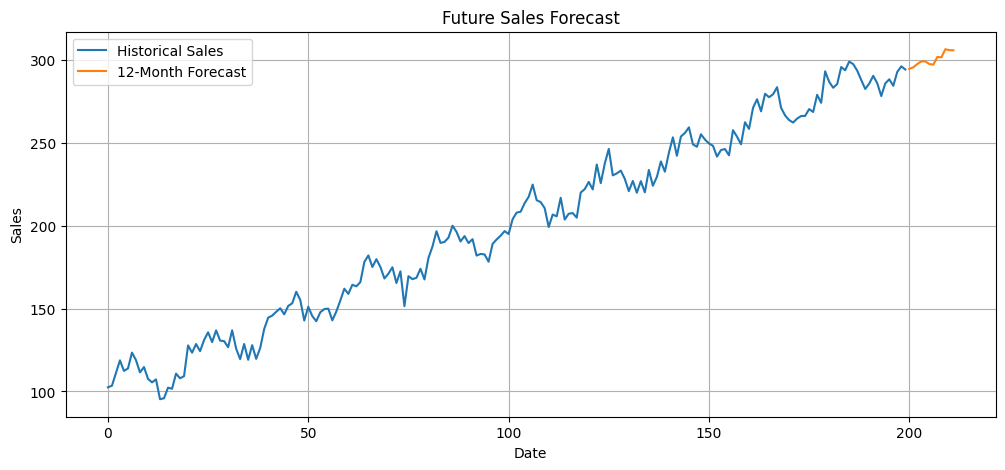

In [67]:
# ------------------------------------------------------------
# 14. Future forecast plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Sales"], label="Historical Sales")
plt.plot(future_forecast.index, future_forecast, label="12-Month Forecast")
plt.title("Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

Here is the formal write-up for the **Future Sales Forecast plot**, consistent with your previous sections.

---

Future Sales Forecast Analysis

1. Purpose
   The purpose of this analysis is to project future sales for the next 12 months using a forecasting model based on historical data. This helps estimate future demand and supports planning and decision-making.

2. Forecast Behavior
   The forecast shows a continuation of the upward trend observed in the historical data. Sales are expected to increase steadily over the forecast period, maintaining the growth pattern established in the past.

3. Alignment with Historical Data
   The forecast begins at the end of the historical series and follows a path that is consistent with previous trends. This indicates that the model has successfully learned the underlying structure of the data and is extending it into the future.

4. Seasonality in Forecast
   The forecast reflects the seasonal pattern present in the historical data, with expected fluctuations that mirror previous cycles. This suggests that the model accounts for recurring monthly variations in sales.

5. Trend Continuation
   The continued upward movement in the forecast indicates that the business is expected to maintain its growth trajectory. The absence of sharp declines suggests stability in future performance based on current trends.

6. Confidence in Forecast
   Because the forecast is based on a model that captures both trend and seasonality, it provides a reasonable estimate of future sales. However, forecasts become less certain further into the future and should be interpreted with caution.

7. Limitations
   The forecast assumes that past patterns will continue unchanged. It does not account for external factors such as economic changes, competition, or unexpected events. As a result, actual future sales may differ from the projected values.

8. Business Implications
   From a business perspective, the forecast indicates continued growth, which may require increased production, inventory, and staffing. The seasonal pattern allows for better planning of high-demand periods. These insights support strategic decisions related to budgeting, resource allocation, and long-term planning.


## SECTION 7: Comparison of Methods

The moving average and linear regression methods both identify an upward trend in sales, but they differ in how they represent the data. The moving average provides a smoothed curve that captures gradual changes and reduces noise, making it easier to see patterns such as seasonality and local fluctuations. In contrast, linear regression produces a straight line that summarizes the overall direction of the data but ignores seasonal effects.

The moving average is more effective for understanding short-term dynamics and identifying patterns over time, while regression is better suited for estimating long-term growth and making forecasts. In this analysis, the moving average provides a more detailed and realistic view of the data, whereas regression offers a simpler, more generalized trend.

Overall, the moving average is more appropriate for exploratory analysis, while linear regression is better for prediction and strategic planning.

## SECTION 8: Limitations

Both methods have limitations that must be considered when interpreting results. The moving average reduces noise but also lags behind the data, meaning it may respond slowly to sudden changes. It also removes some important information, such as extreme values or sharp shifts, which may be meaningful for decision-making.

Linear regression assumes a constant linear relationship, which may oversimplify real-world data. It ignores seasonality and is sensitive to outliers, which can distort the trend line. Additionally, regression assumes that past trends will continue into the future, which may not always be true in dynamic business environments.

Because of these limitations, it is important to use both methods together to gain a more complete understanding of the data.

## SECTION 9: Business Implications

From a business perspective, the analysis indicates that sales are steadily increasing over time, suggesting strong performance and growing demand. The presence of seasonality implies that certain periods consistently generate higher sales, which can inform inventory planning, staffing decisions, and marketing strategies.

The moving average helps identify stable growth trends, which can support long-term planning and resource allocation. Meanwhile, the regression model provides a basis for forecasting future sales, helping organizations make data-driven decisions.

However, decision-makers should be cautious when relying solely on these models, as they do not account for external factors such as market changes, competition, or economic conditions. Combining these insights with business context leads to more effective and informed strategies.